In [1]:
import pandas as pd
import numpy as np

In [14]:
data = pd.read_csv("auto-mpg.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [17]:
# data.info()
# Seems horsepower had ? in its value
data[data['horsepower']=="?"].value_counts()

mpg   cylinders  displacement  horsepower  weight  acceleration  model_year  origin  car_name            
25.0  4          98.0          ?           2046    19.0          71          1       ford pinto              1
21.0  6          200.0         ?           2875    17.0          74          1       ford maverick           1
40.9  4          85.0          ?           1835    17.3          80          2       renault lecar deluxe    1
23.6  4          140.0         ?           2905    14.3          80          1       ford mustang cobra      1
34.5  4          100.0         ?           2320    15.8          81          2       renault 18i             1
23.0  4          151.0         ?           3035    20.5          82          1       amc concord dl          1
Name: count, dtype: int64

In [24]:
# We will replace the ? with nan and then change the whole column to numeric
data['horsepower'] = data['horsepower'].replace('?', np.nan)
data['horsepower'] = pd.to_numeric(data['horsepower'])
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [28]:
# Since data['horsepower'] column has oly 6 nan values we will fill thm with the median of the horsepower
median_horsepower = data['horsepower'].median()
data['horsepower'] = data['horsepower'].fillna(median_horsepower)
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [37]:
# Car_name doesn't really matter when it comes to fuel efficiency and this column is has string data and is useless for us. So we will drop this column.
data = data.drop('car_name', axis=1)

In [38]:
# Now the data is clean we will Separate the target and features
from sklearn.model_selection import train_test_split
y = data['mpg']
features = data.drop('mpg', axis=1)

In [39]:
# Train Test and split
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

In [41]:
# Model import and training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0.16, 0.01,-0.01,..., 0.07, 0.79, 1.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['cylinders','displacement','horsepower',...,'acceleration','model_year', 'origin']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-20.56
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [43]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[32.88140046 29.55780381 21.36955005 16.79734409 12.4982001 ]


In [46]:
# Now we have the prediction we can evaluate the model 
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r_score = r2_score(y_test, y_pred)
print(mse, r_score)

8.197746885824987 0.8475304239212402


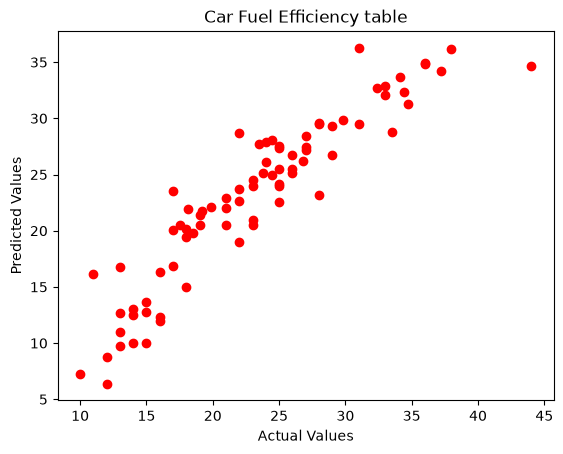

In [48]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, color='red')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Car Fuel Efficiency table')
plt.show()

## This dataset is great and understandable.
The horsepower numerical data were in string format and also had '?' so changed '?' to np.nan values and whole column to numeric data type for machine learning.
And there were only 6 nan values on horsepower so dropping the whole column or those nan values would negatively affect machine learning so I filled those nan values with medain horsepower as median is more accurate than mean.
The car_name had nothing to do with the fuel efficiency and was useless. So I dropped that column. 
Then when all data were numeric and no nan values
- I defined mpg as target and other columns as features.
- trained with linear regression model
- measured mse and r2 score
- plotted the scatter plot which looks our model did well